In [84]:
import numpy as np
import matplotlib.pyplot as plt

\begin{equation}
\frac d{dt} \begin{pmatrix} v_1 \\ v_2 \end{pmatrix} = \begin{pmatrix} -i\lambda && q(t) \\ - \bar q(t) && i\lambda \end{pmatrix} \begin{pmatrix} v_1 \\ v_2 \end{pmatrix}
\end{equation}

\begin{equation}
\tilde v_1(t) = e^{+i\lambda t}v_1(t), \quad \tilde v_2(t) = e^{-i\lambda t} v_2(t)
\end{equation}

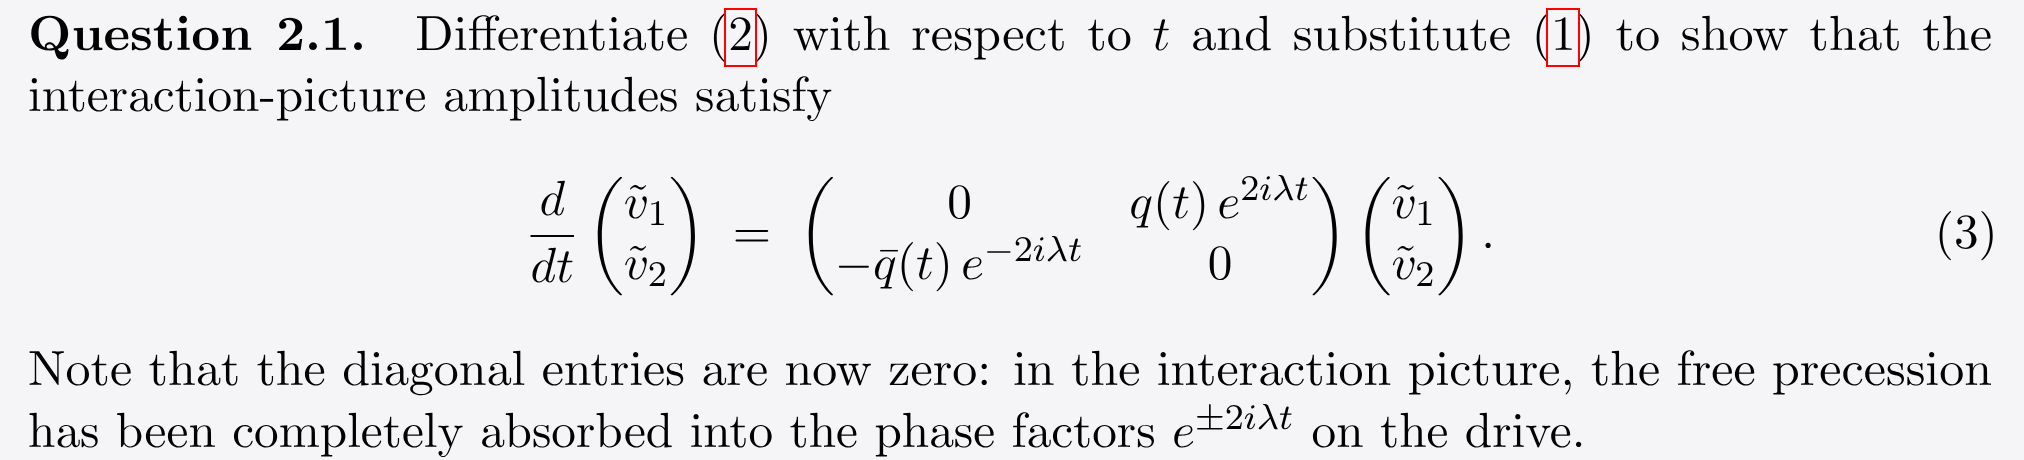


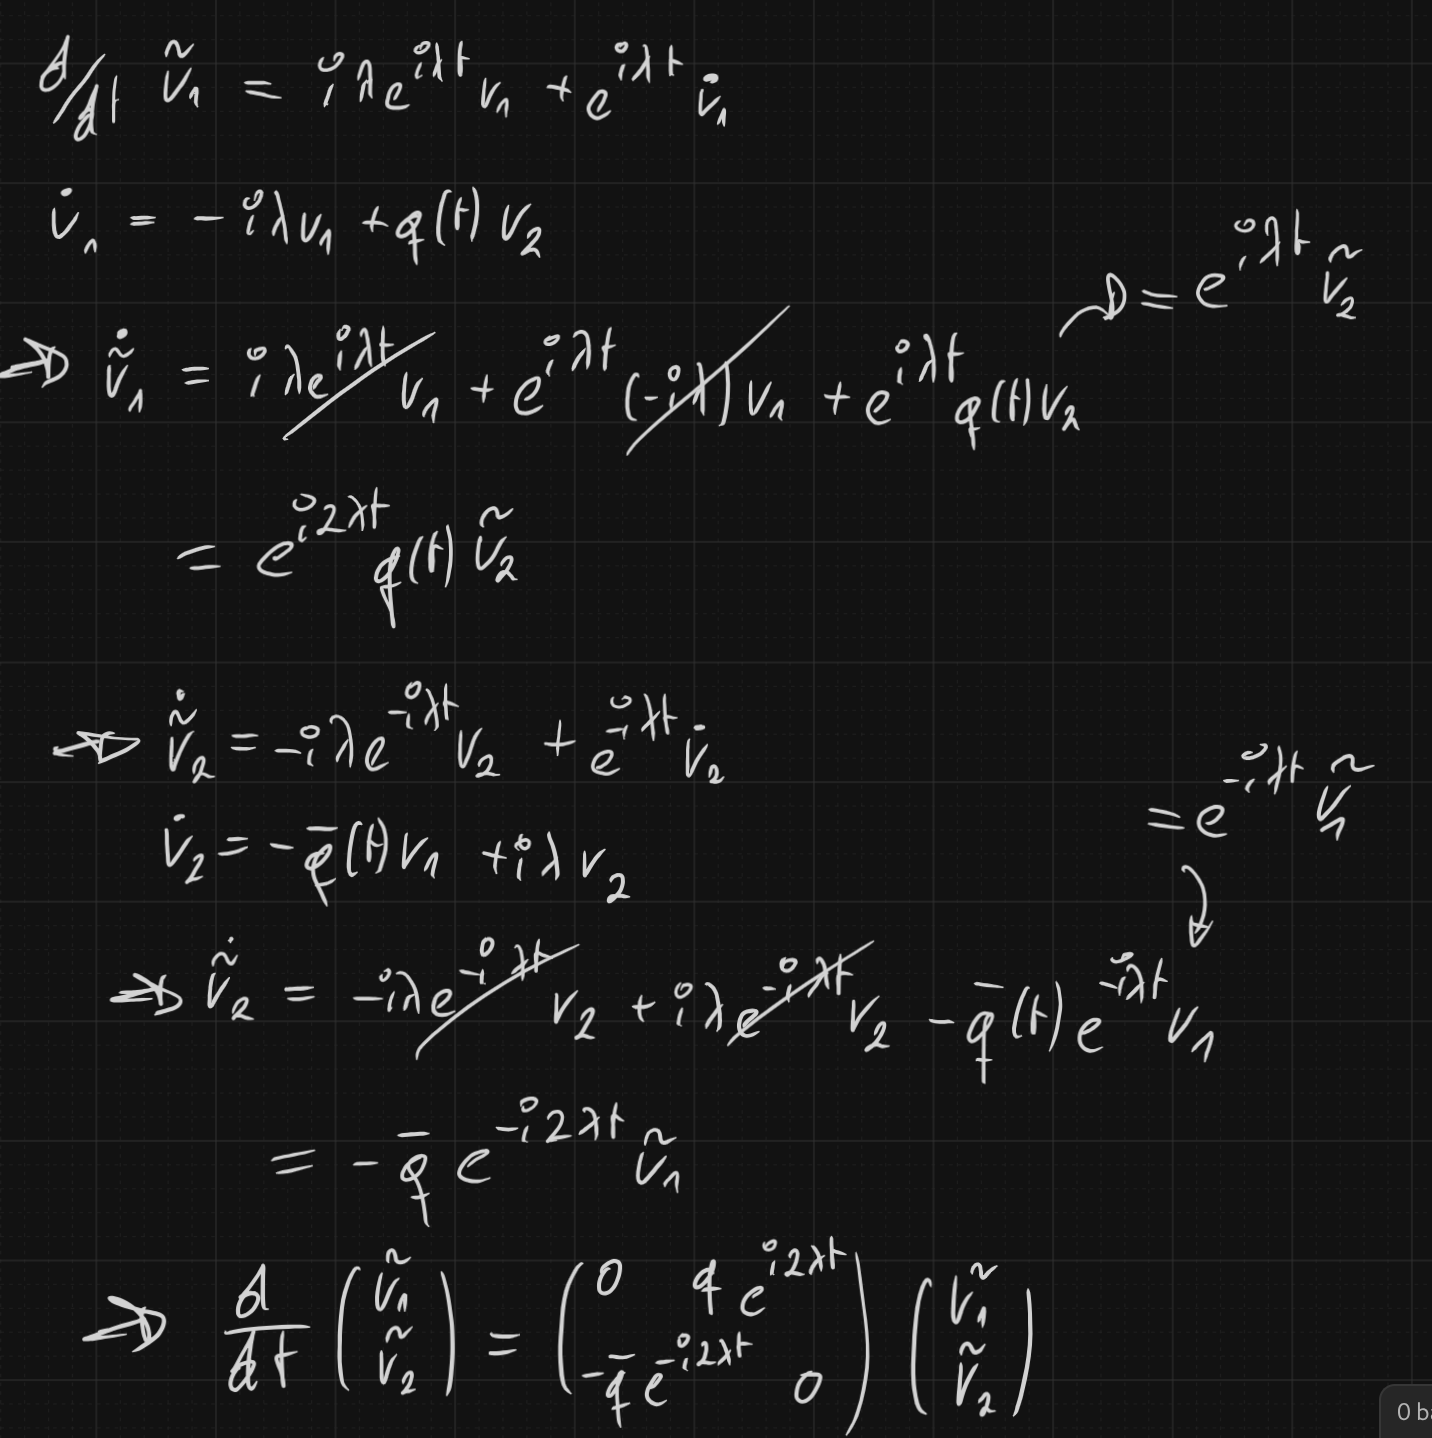

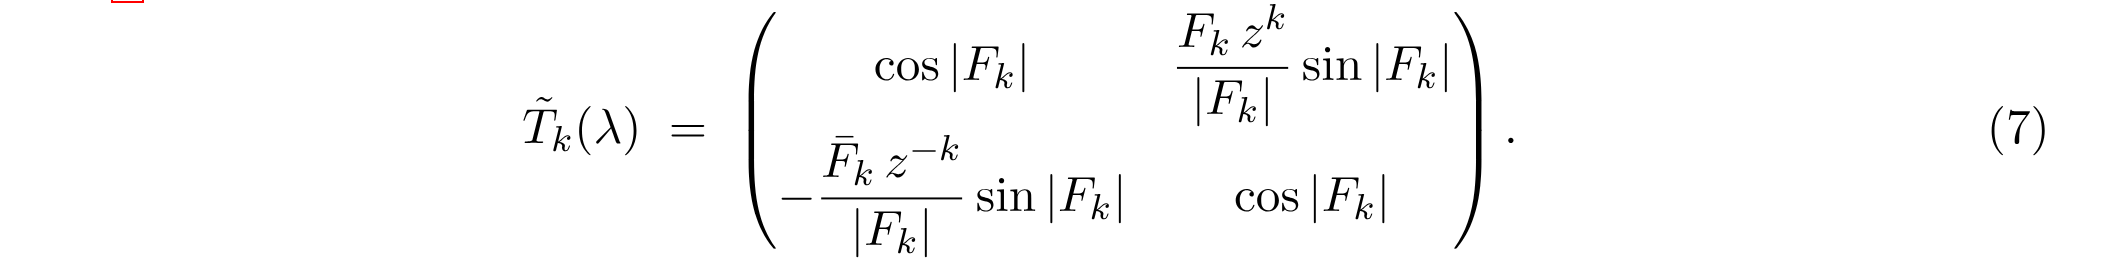
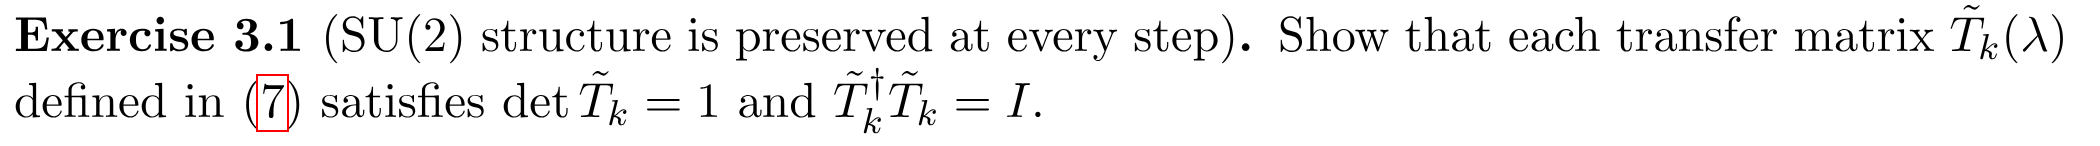

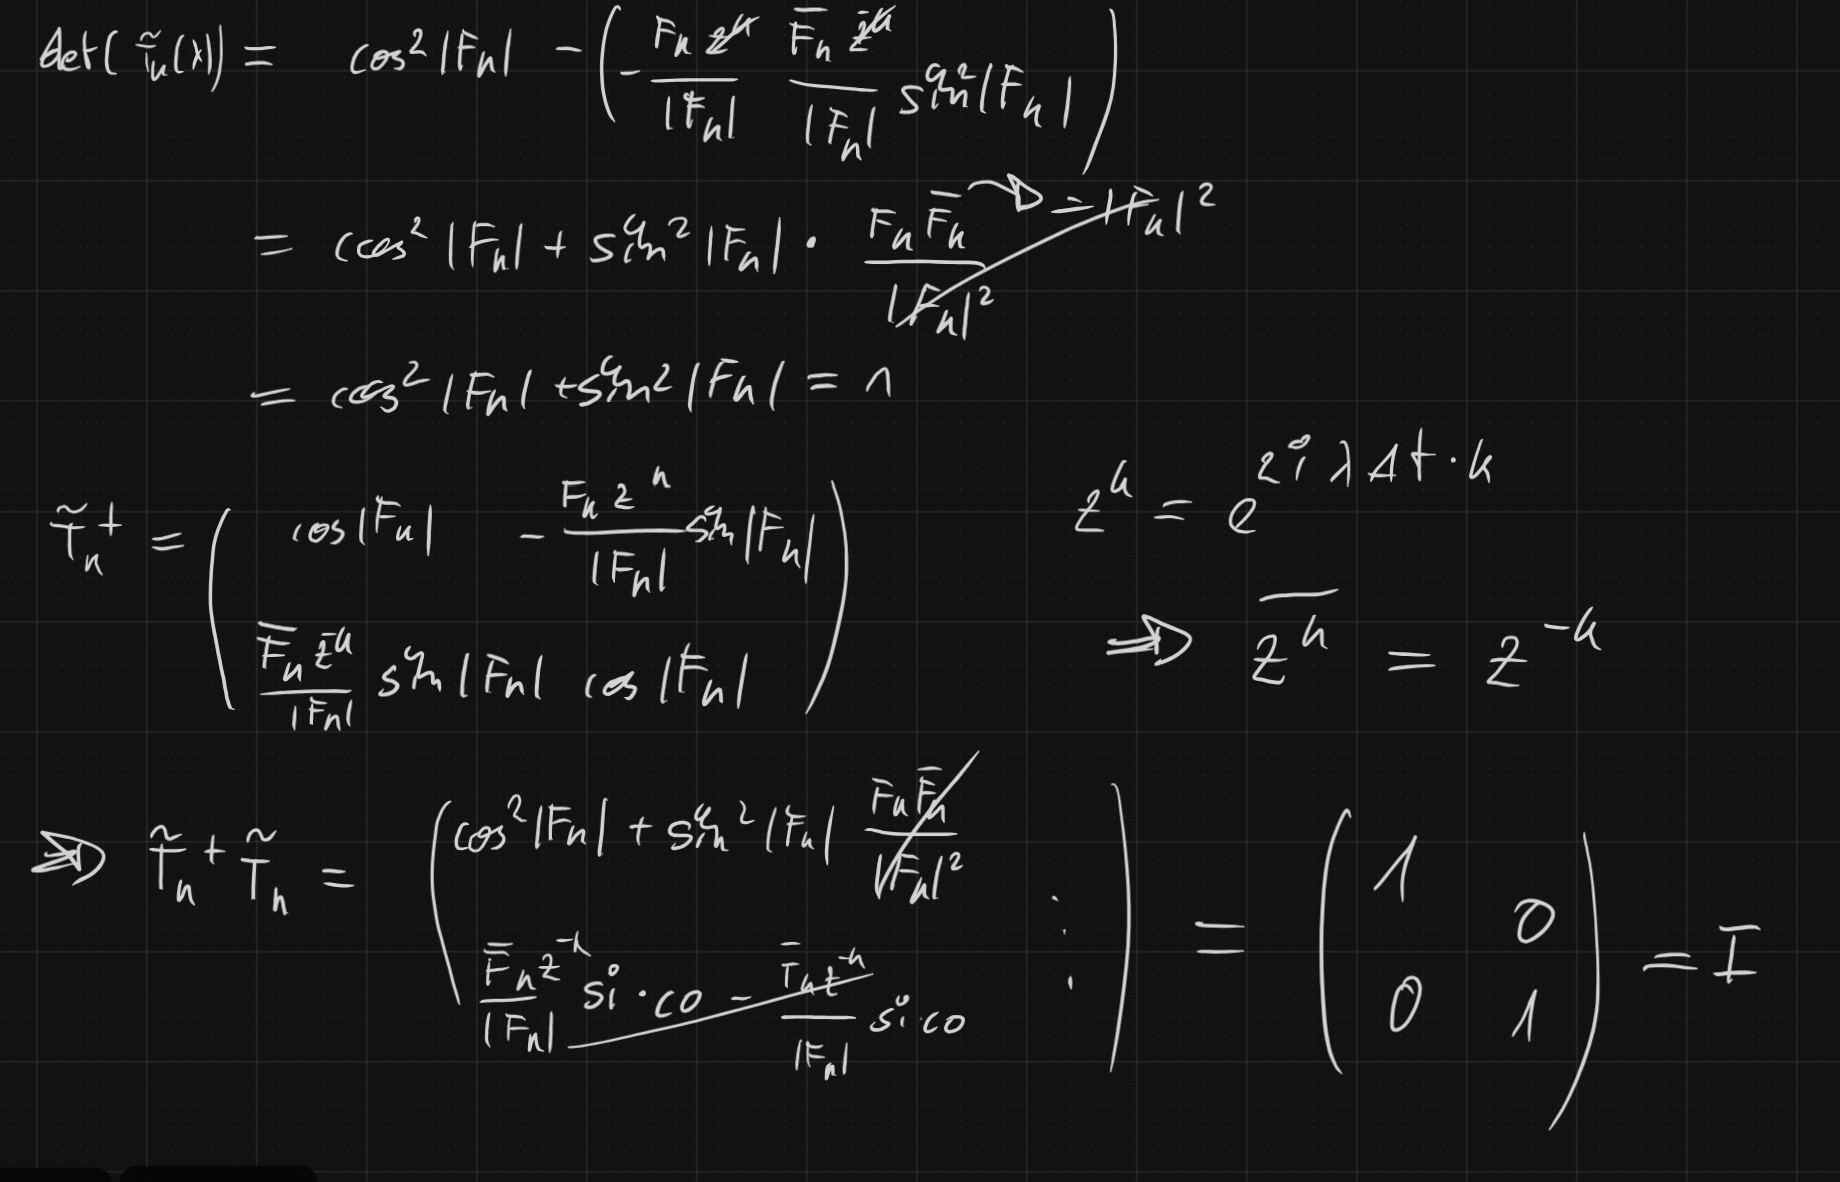

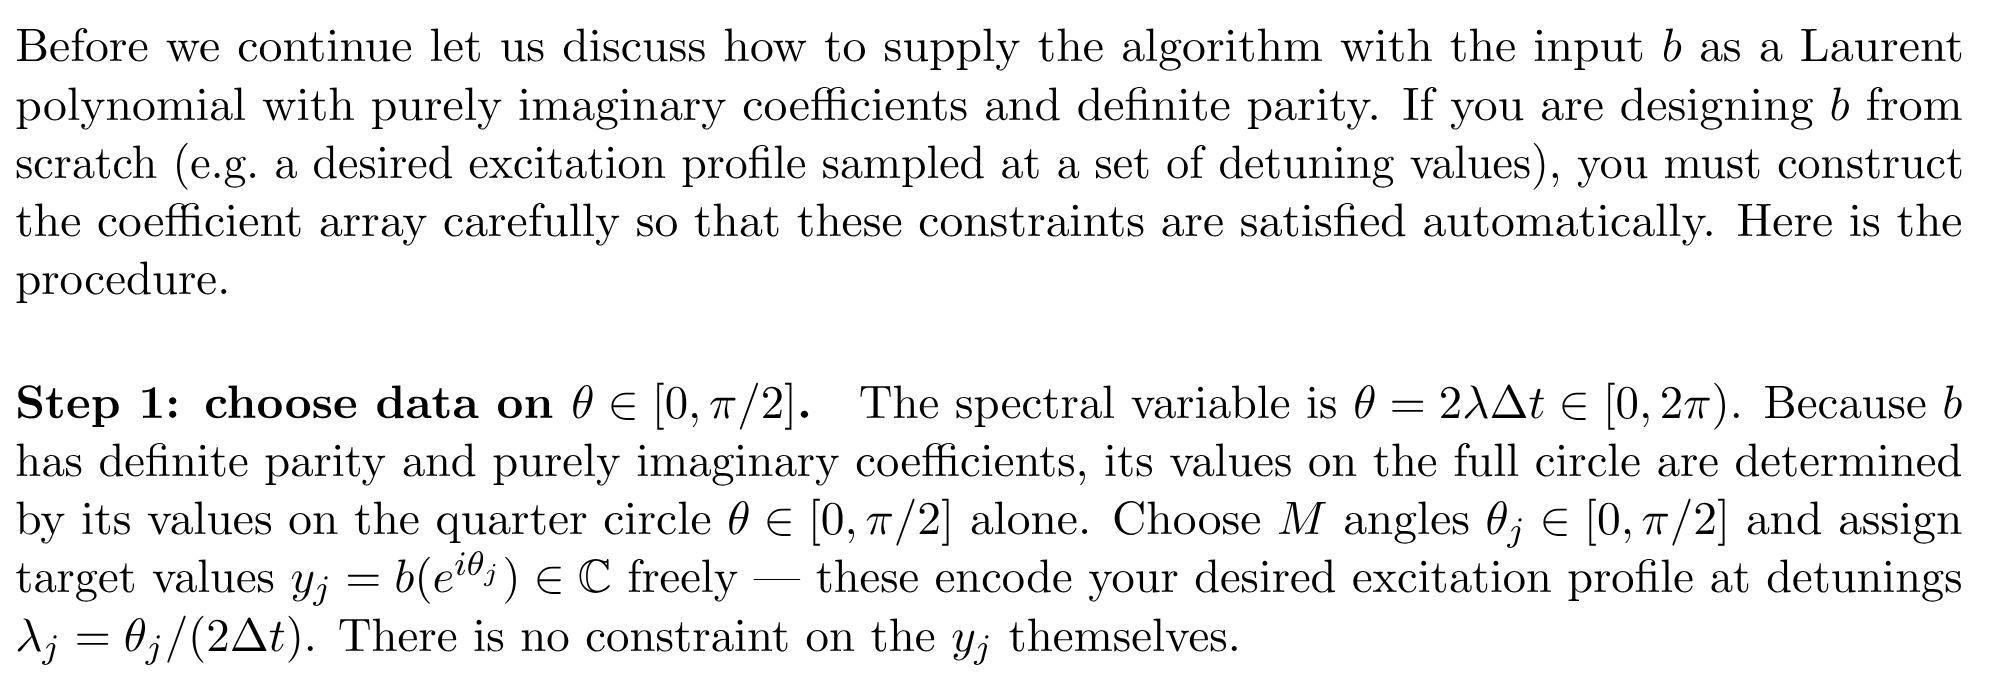

In [85]:
import random

def get_random_target(M):
    theta = np.array([j*np.pi/(2*M) for j in range(M+1)])
    y = np.array([complex(random.uniform(-1,1), random.uniform(-1,1)) for _ in theta])
    y[0] = 1j*y[0].imag          # θ=0 is an X-constraint fixed point → must be purely imaginary
    return theta, y

def get_random_target_unit_disk(M):
    theta = np.array([j*np.pi/(2*M) for j in range(M+1)])
    def rand_in_disk():                       
        while True:
            v = complex(random.uniform(-1, 1), random.uniform(-1, 1))
            if abs(v) < .5:
                return v

    y = np.array([rand_in_disk() for _ in theta])
    y[0] = 1j * y[0].imag                      # θ=0 stays purely imaginary (|y[0]| < 1 still)
    return theta, y


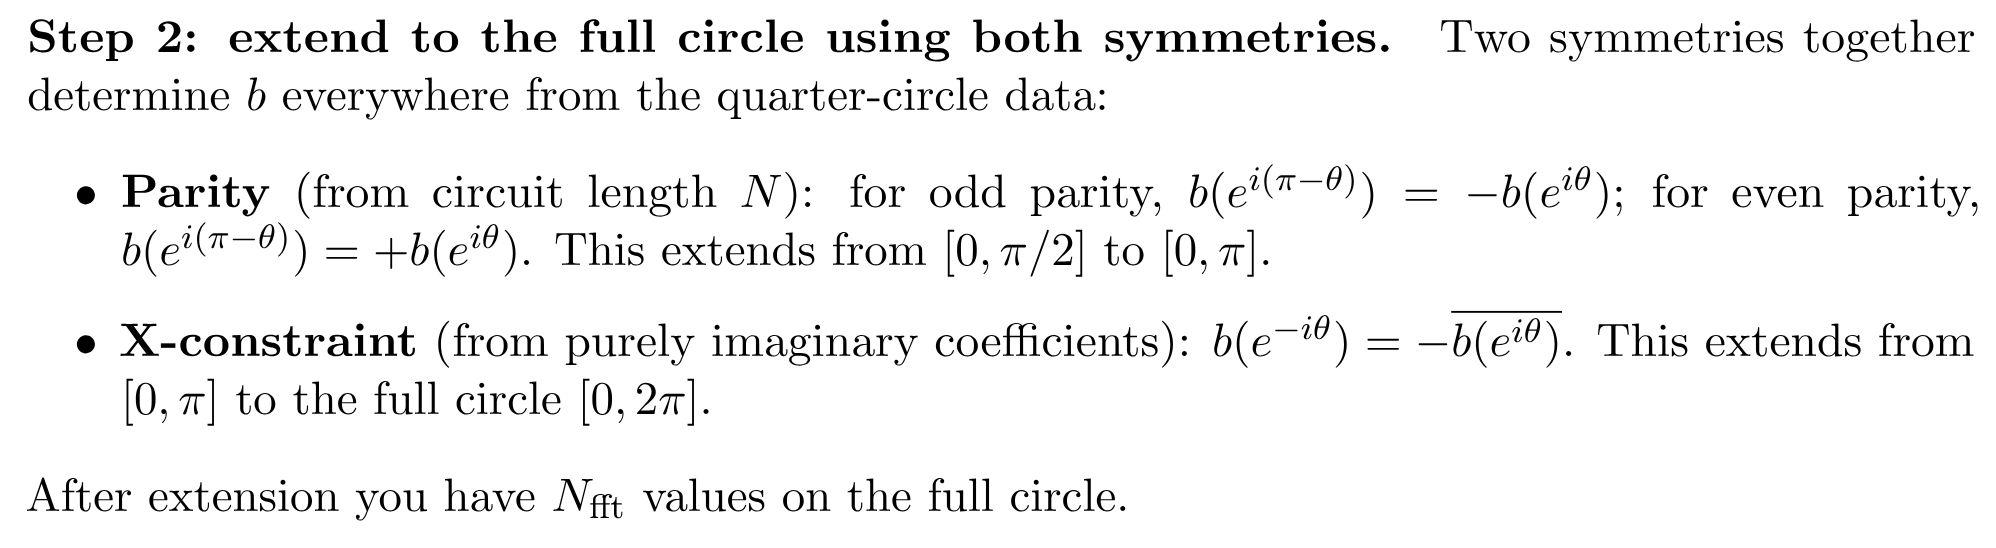

In [86]:
def extend_target(quarter, parity = "even"):
    t, y = quarter
    y = y.astype(complex).copy()
    sign = 1 if parity == "even" else -1
    if parity == "odd":
        y[-1] = 0j               # θ=π/2 is forced to 0 for odd parity

    # parity: reflect across π/2 without the endpoint to avoid duplicating
    t = np.append(t, (np.pi - t[:-1])[::-1])
    y = np.append(y, (sign * y[:-1])[::-1])

    # X-constraint: reflect across 0 without 0,pi points to avoid duplicating
    t = np.append((-t[1:-1])[::-1], t)
    y = np.append((-1*np.conjugate(y[1:-1]))[::-1], y)
    return t,y

In [87]:
def convert_order_linear_to_fft(arr):
    n = len(arr)
    res = np.concat([arr[n//2-1:], arr[:n//2-1]])
    assert len(res) == len(arr)
    return res

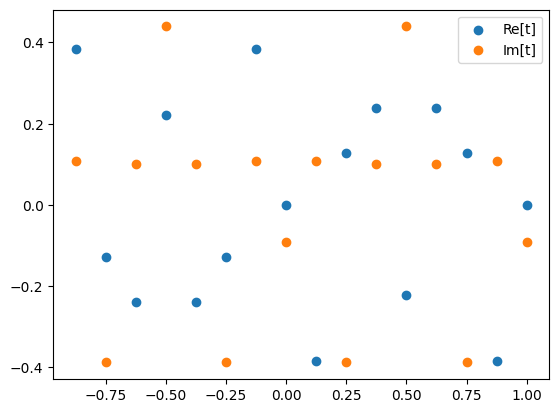

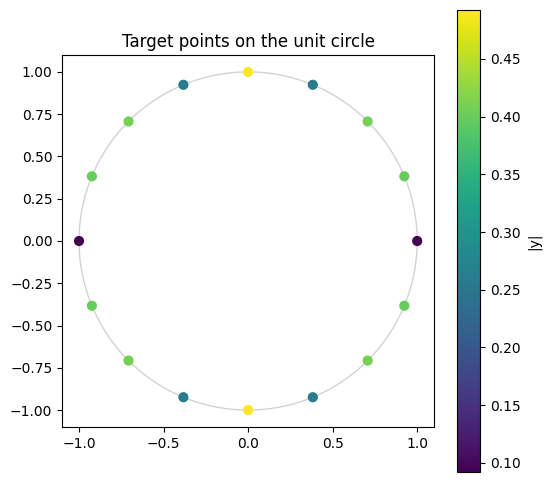

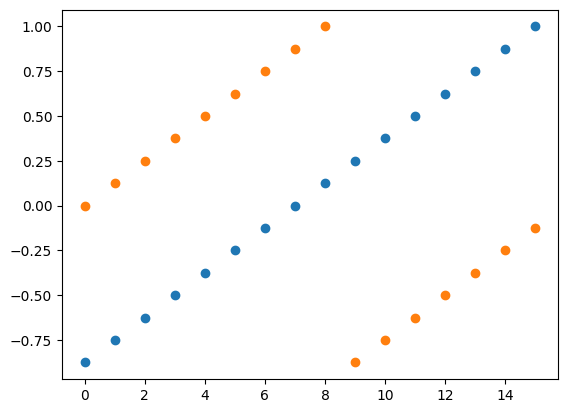

In [88]:
N_fft = 16

t = get_random_target_unit_disk(N_fft // 4)
t = extend_target(t)

plt.scatter(t[0] / np.pi, t[1].real, label="Re[t]")
plt.scatter(t[0] / np.pi, t[1].imag, label="Im[t]")
plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6,6))
thetas = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(thetas), np.sin(thetas), color="lightgray", lw=1, zorder=0)
sc = ax.scatter(np.cos(t[0]), np.sin(t[0]), c=np.abs(t[1]), cmap="viridis", s=40, zorder=1)
fig.colorbar(sc, ax=ax, label="|y|")
ax.set_aspect("equal")       
ax.set_title("Target points on the unit circle")
plt.show()


plt.scatter(np.arange(len(t[0])), t[0] / np.pi)
plt.scatter(np.arange(len(t[0])), convert_order_linear_to_fft(t[0]) / np.pi)
plt.show()

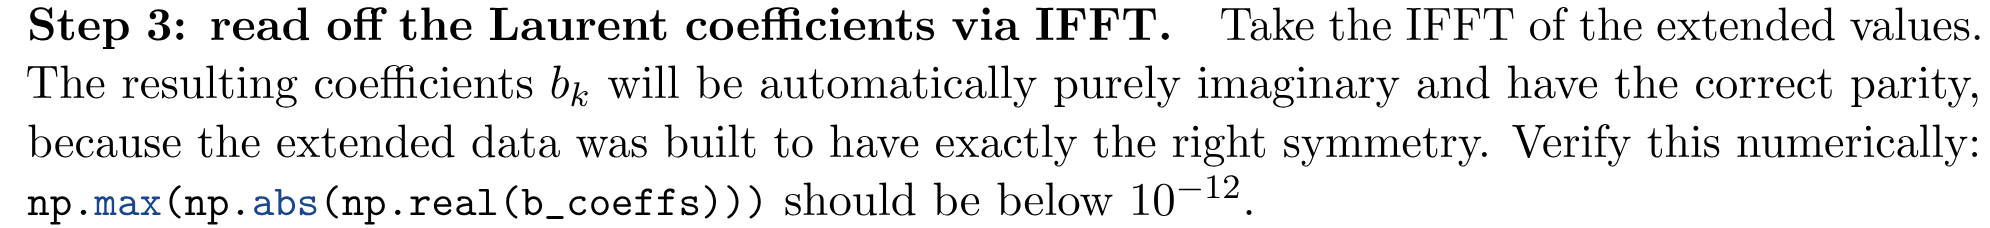

In [89]:
class LaurentPoly:
    def __init__(self, c, k, sign):
        assert sign == 1 or sign == -1, "sign argument may only be +-1"
        self.c = c
        self.ks = k
        self.sign = sign

    def __call__(self, t):
        theta = np.asarray(t, dtype=float)
        return np.exp(1j * theta[..., None] * self.ks * self.sign) @ self.c

def calc_poly_err(p, target_pts):
    p_vals = p(target_pts[0])
    errs = np.abs(p_vals - target_pts[1])
    return sum(errs)

def get_laurent_poly(thetas, ys, sign, check=True):
    n = len(ys)
    c = np.fft.ifft(ys)
    f = np.fft.fftfreq(n, d=1.0/n).astype(int)
    p = LaurentPoly(c, f, sign)
    assert calc_poly_err(p, (thetas, ys)) <= 1e-8 or not check, "Could not fit with necessary precision!"
    return p

b = get_laurent_poly(t[0], convert_order_linear_to_fft(t[1]), -1, check=False)
assert np.max(np.abs(np.real(b.c))) <= 1e-12, "b_k should all be purely imaginary!"

Poly error: 2.4212591186506794e-15


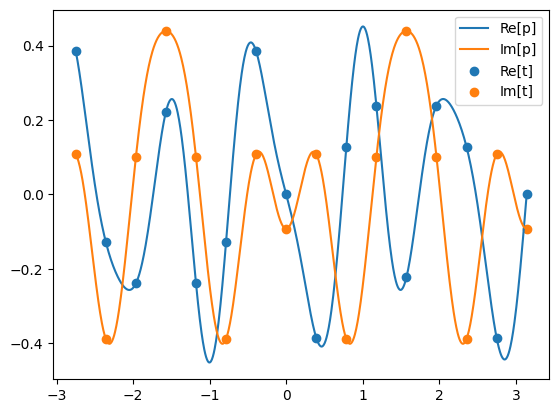

In [90]:


def plt_poly_and_compare(p, target_pts):
    print(f"Poly error: {calc_poly_err(p, target_pts)}")
    ts = target_pts[0]
    thetas = np.linspace(np.min(ts), np.max(ts), 1000, endpoint=False)
    
    plt.plot(thetas, p(thetas).real, label="Re[p]")
    plt.plot(thetas, p(thetas).imag, label="Im[p]")
    #plt.plot(thetas, np.abs(p(thetas)), label="Mag[p]")
    plt.scatter(target_pts[0], target_pts[1].real, label="Re[t]")
    plt.scatter(target_pts[0], target_pts[1].imag, label="Im[t]")
    plt.legend()
    plt.show()

plt_poly_and_compare(b, t)

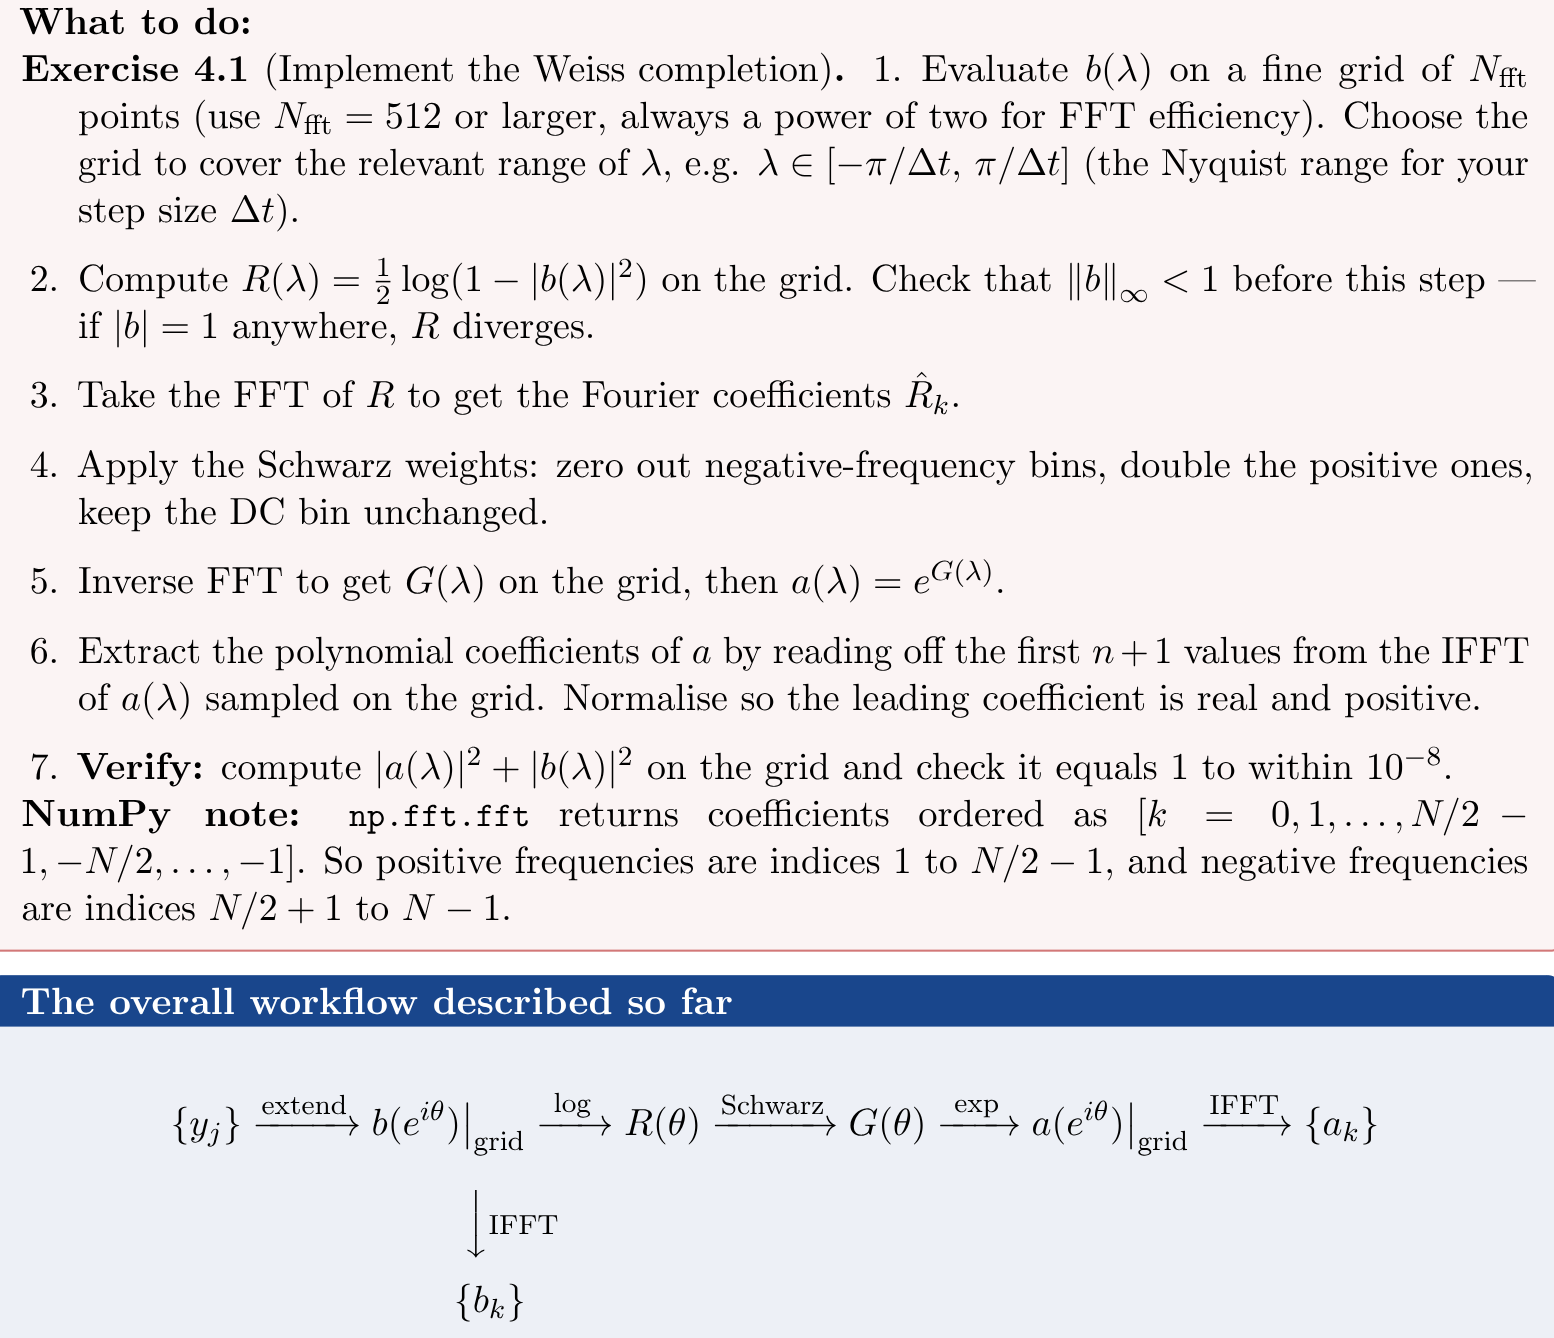

In [91]:
def R(b_lambdas):
    assert all(np.abs(b) < 1 for b in b_lambdas), "||b(λ)||_∞ < 1 does not hold! This would cause divergence in R!"
    return 0.5 * np.log(1-np.square(np.abs(b_lambdas)))

def schwarz_weights(fft_coeffs):
    n = len(fft_coeffs)
    assert n % 2 == 0, "Uneven coefficient array!"
    res = fft_coeffs.copy()
    res[1:n//2] *= 2
    res[n//2+1:] = 0
    #res[1:n//2] = 0
    #res[n//2+1:] *= 2
    assert len(res) == n, f"Schwarz weights changed coeff array size! Was {n}, now {len(res)}"
    return res

def recover_a(b: LaurentPoly, N):
    grid = np.linspace(0, 2*np.pi, N, endpoint=False)
    bs = b(grid)
    
    grid_R = R(bs)
    r_k = np.fft.fft(grid_R)
    r_k = schwarz_weights(r_k)

    grid_G = np.fft.ifft(r_k)
    grid_a = np.exp(grid_G) 
    assert np.max(np.abs((np.square(np.abs(grid_a)) + np.square(np.abs(bs))) - 1)) <= 1e-8, "Got incorrect a: |a(λ)|^2 + |b(λ)|^2 = 1 does not hold."
    
    n=len(b.c)
    c = np.fft.fft(grid_a) / len(grid_a)
    f = np.fft.fftfreq(N, d=1/N).astype(int)
    
    a_k = c[:n]
    k = f[:n]

    a = LaurentPoly(a_k, k, 1)
    
    #assert np.max(np.abs((np.square(np.abs(a(grid))) + np.square(np.abs(bs))) - 1)) <= 1e-8, "Got incorrect a: |a(λ)|^2 + |b(λ)|^2 = 1 does not hold."

    return a, (grid, grid_a)

def recover_a_arr(b_arr, N):
    N = len(b_arr)
    ks = np.arange(N)
    grid = np.linspace(0, 2*np.pi, Nfft, endpoint=False)

    bg = np.exp(-1j*grid[..., None]*ks) @ b_arr          # evaluate b (sign=-1)
    R = 0.5*np.log(1 - np.abs(bg)**2)
    rk = np.fft.fft(R); n = len(rk)
    G = np.zeros_like(rk); G[0] = rk[0]; G[n//2] = rk[n//2]
    G[n//2+1:] = 2*rk[n//2+1:]                             
    ag = np.exp(np.fft.ifft(G))
    ca = np.fft.ifft(ag); ff = np.fft.fftfreq(Nfft, d=1/Nfft).astype(int)
    a_arr = np.zeros(N, complex)
    for k, v in zip(ff, ca):
        if 0 <= k < N: a_arr[k] = v
    return a_arr

Poly error: 3.2200667473466274e-13


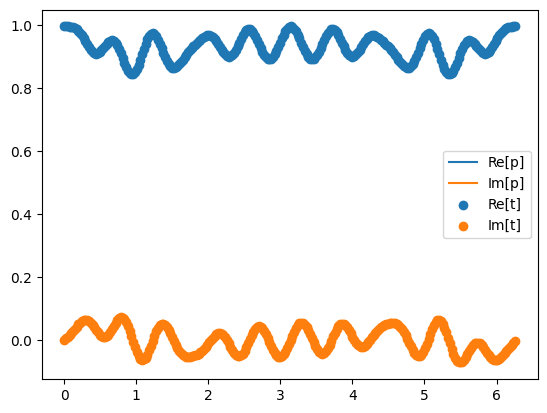

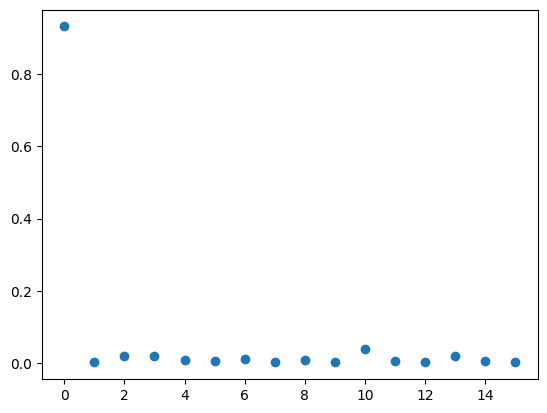

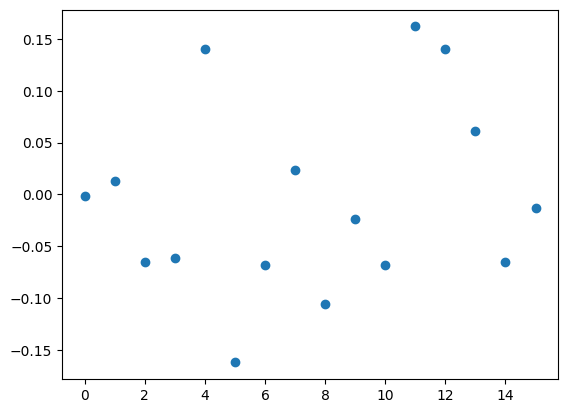

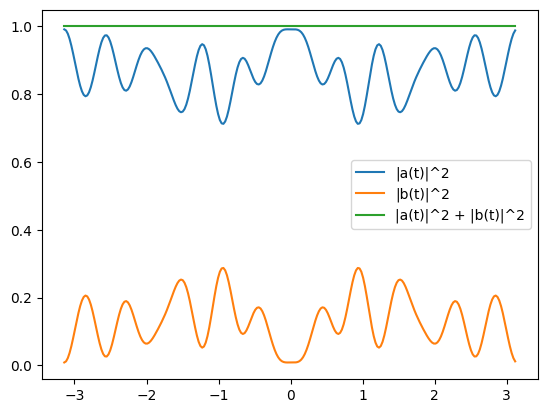

In [92]:
a,t = recover_a(b, N_fft**2)
plt_poly_and_compare(a, t)

plt.scatter(np.arange(len(a.c)), np.abs(a.c))
plt.show()

plt.scatter(np.arange(len(b.c)), b.c.imag)
plt.show()


t = np.linspace(-np.pi, np.pi, N_fft ** 2, endpoint=False)
plt.plot(t, np.square(np.abs(a(t))), label="|a(t)|^2")
plt.plot(t, np.square(np.abs(b(t))), label="|b(t)|^2")
plt.plot(t, np.square(np.abs(a(t))) + np.square(np.abs(b(t))), label="|a(t)|^2 + |b(t)|^2")
plt.legend()
plt.show()

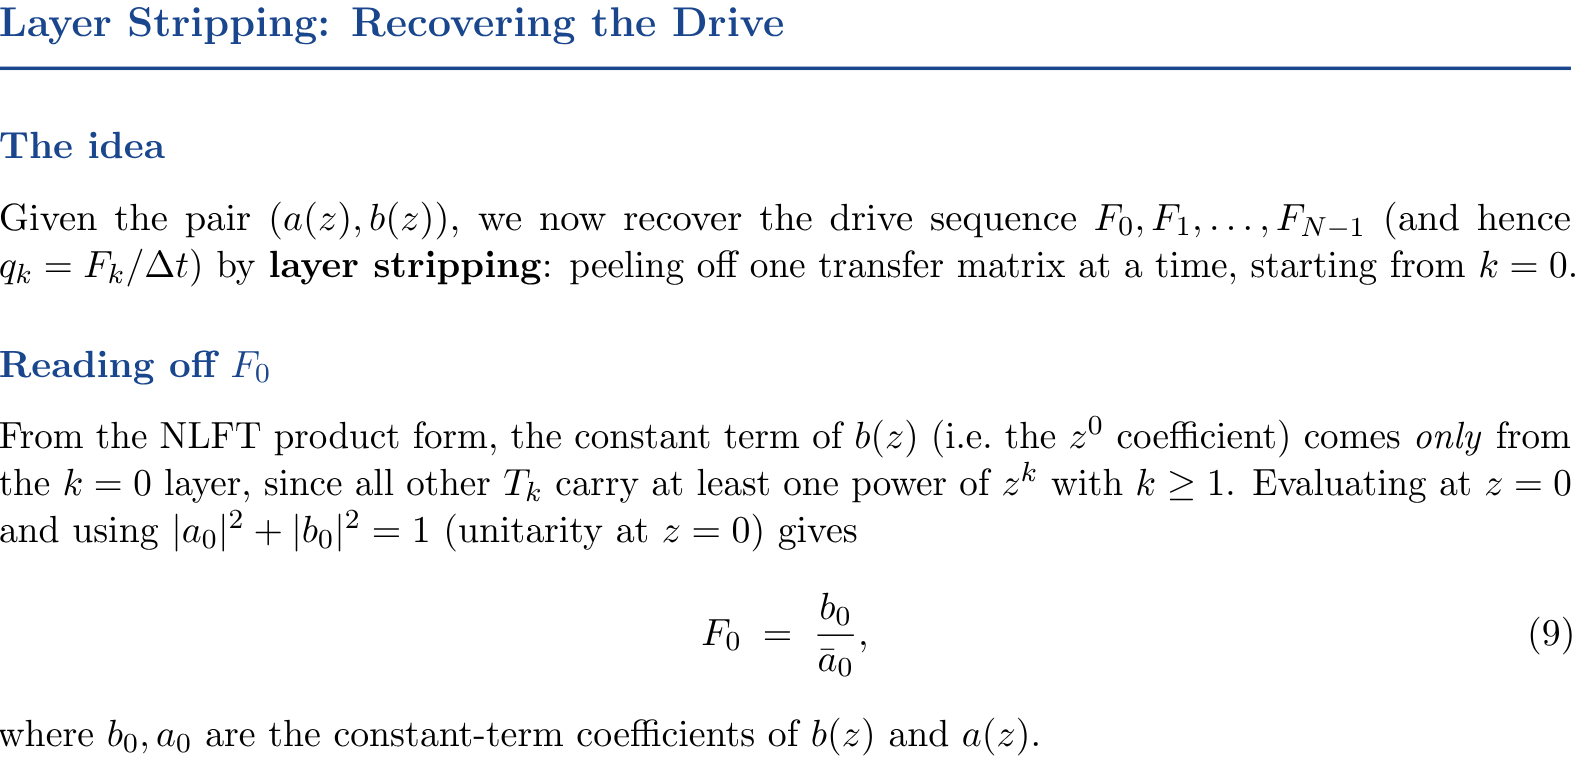
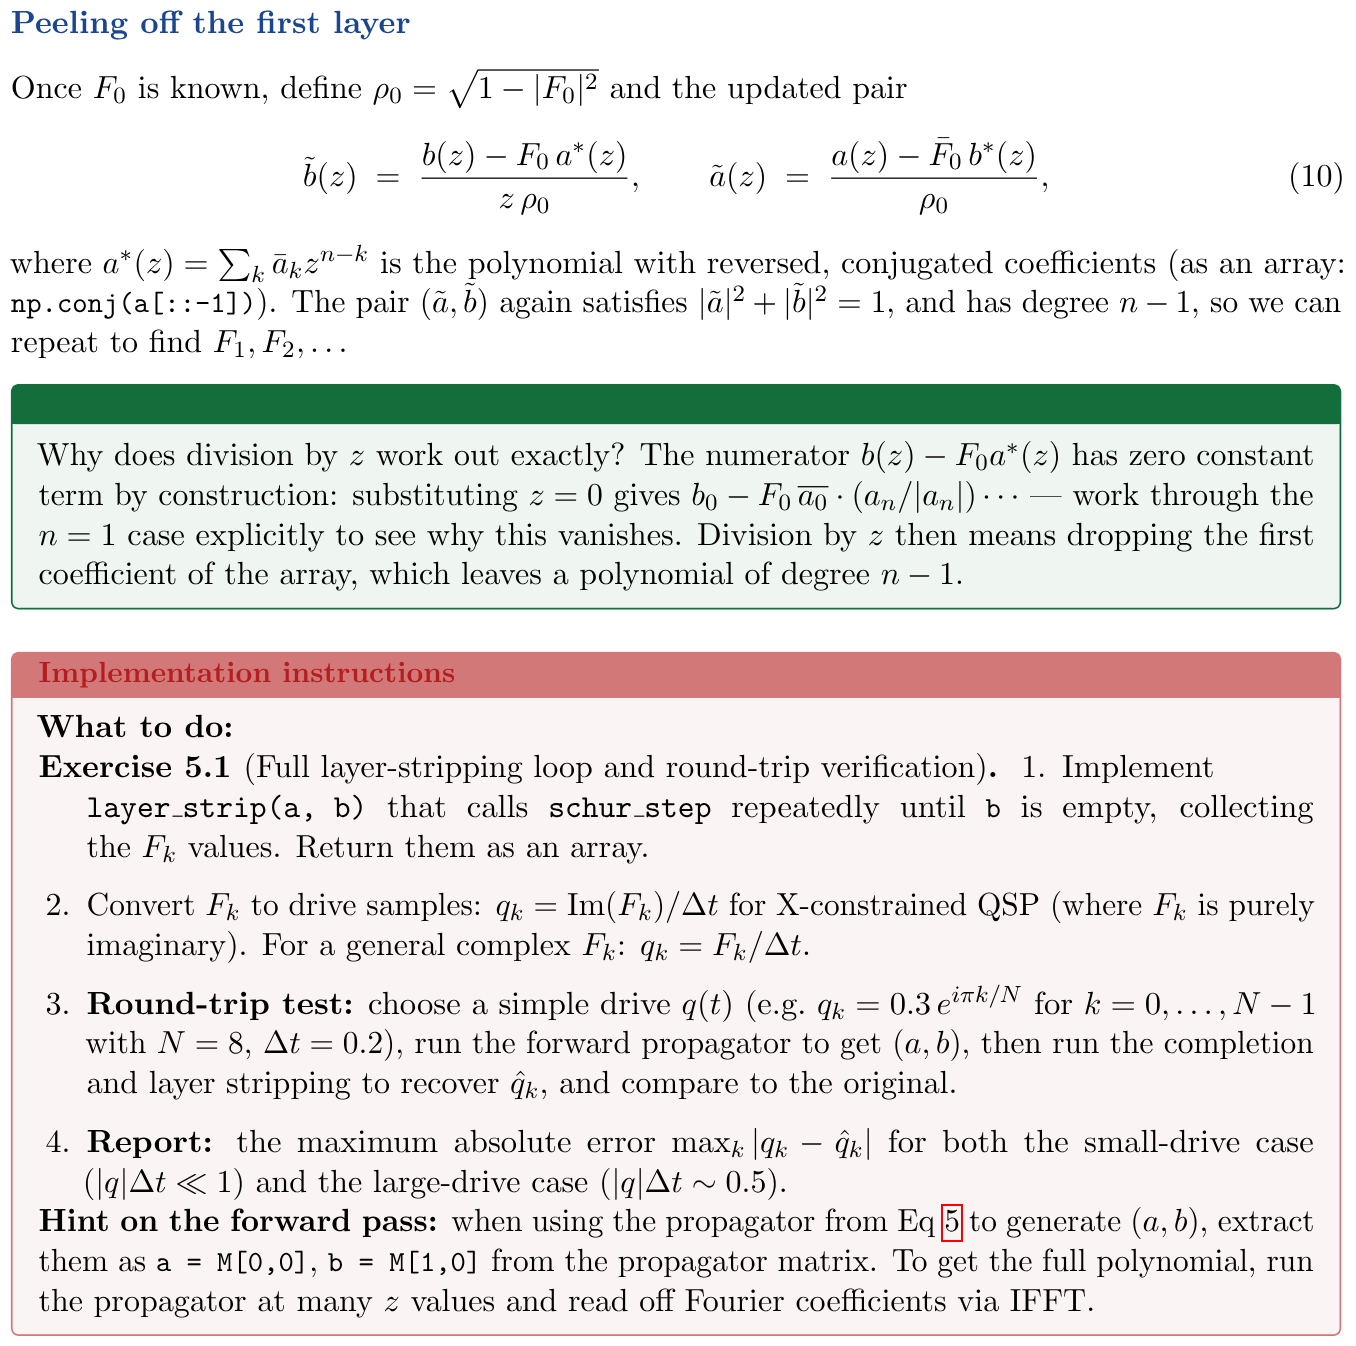

In [93]:
def layer_strip(a, b):
    # a, b are a*(z)=M[1,1] and b*(z)=-M[1,0], as NON-NEGATIVE power arrays
    # index 0 = z^0 (constant), index n = z^n. Both length n+1.
    a = np.asarray(a, complex).copy()
    b = np.asarray(b, complex).copy()
    Fs = []
    while len(b) > 0:
        F   = np.conj(b[0] / a[0])          # constant terms; conj wraps the WHOLE ratio
        c   = 1 / np.sqrt(1 + np.abs(F)**2) # == 1/rho, same as your +sign
        a_n = c * (a + F * b)               # PLAIN b
        b_n = c * (b - np.conj(F) * a)      # PLAIN a, and conj(F)
        Fs.append(F)
        a = a_n[:-1]                        # drop TOP power
        b = b_n[1:]                         # drop constant  (= divide by z)
    return np.array(Fs)

In [94]:
def recover_drive(a_star, b_star, dt):
    assert len(a_star) == len(b_star), f"recover drive got coefficient arrays of different size! len(a*)={len(a_star)}, len(b*)={len(b_star)}"
    Fs = layer_strip(a_star, b_star)
    return Fs, Fs/dt        # qk = Fk/dt  (general complex drive)

def star_poly(p):
    return np.conj(p.c[::-1])

recover_drive(star_poly(a), star_poly(b), .1)

(array([-7.85017669e-15-4.90288666j, -4.80486699e-15-1.48846929j,
         5.73639145e-15+2.01997219j, -3.53787544e-15-0.94891326j,
        -7.48978926e-16-0.02799983j, -4.36833894e-15-0.73622676j,
        -2.11621525e-15-0.24648628j, -5.57511592e-15-0.89873593j,
        -3.61229356e-15-0.56756287j, -2.65101906e-17+0.10352514j,
        -3.61727062e-15-0.69242796j,  6.66648607e-16+0.18413316j,
        -3.37014611e-16-0.03296829j, -1.68651903e-15-0.36128157j,
         2.01828681e-15+0.40872623j, -1.38299697e-15-0.20527453j]),
 array([-7.85017669e-14-49.02886662j, -4.80486699e-14-14.88469287j,
         5.73639145e-14+20.19972188j, -3.53787544e-14 -9.48913257j,
        -7.48978926e-15 -0.27999831j, -4.36833894e-14 -7.36226764j,
        -2.11621525e-14 -2.46486284j, -5.57511592e-14 -8.9873593j ,
        -3.61229356e-14 -5.67562872j, -2.65101906e-16 +1.03525145j,
        -3.61727062e-14 -6.92427965j,  6.66648607e-15 +1.84133161j,
        -3.37014611e-15 -0.32968291j, -1.68651903e-14 -3.61281

In [95]:
import scipy as sp

def L_k(q, k, dt, l):
    return np.array([
            [0,                                     q * np.exp(2j*l*k*dt)   ], 
            [-np.conj(q) * np.exp(-2j*l*k*dt),  0                           ]
            ])

def propagator(q_ks, dt, l):
    T = np.eye(2)
    for (k, q_k) in enumerate(q_ks):
        T = sp.linalg.expm(L_k(q_k, k, dt, l) * dt) @ T
    return T



recov len: 24


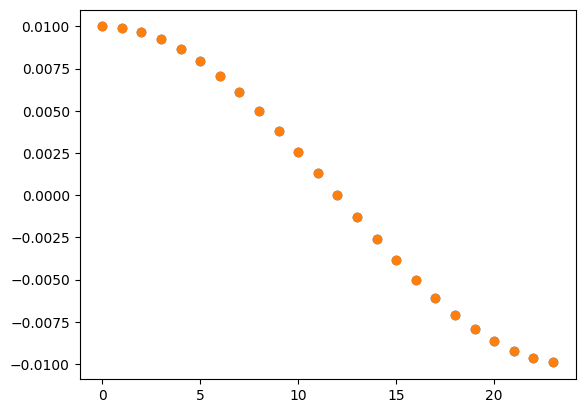

Max err (small-drive, |q|·Δt = 0.002): 1.3333354679766696e-08
recov len: 24


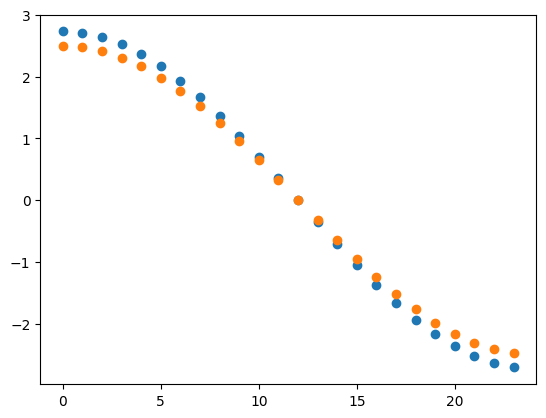

Max err (large-drive, |q|·Δt = 0.5): 0.23151244923373782


In [96]:

def round_trip(q_k, Nfft=256, dt=0.2):
    N = len(q_k)

    lam = np.linspace(0, np.pi/dt, Nfft, endpoint=False)   # theta = 2*lam*dt in [0,2pi)
    Ts  = np.array([propagator(q_k, dt, l) for l in lam])
    n   = N - 1

    def coeffs(vals):
        c = np.fft.ifft(vals)
        f = np.fft.fftfreq(Nfft, d=1/Nfft).astype(int)
        arr = np.zeros(n+1, complex)
        for k, v in zip(f, c):
            if 0 <= k <= n: arr[int(k)] = v
        return arr

    a_star_k, b_star_k = coeffs(Ts[:,1,1]), -coeffs(Ts[:,1,0])

    Fs, q_k_recov = recover_drive(a_star_k, b_star_k, dt)


    print(f"recov len: {len(Fs)}")

    plt.scatter(np.arange(len(q_k_recov)), q_k_recov.real)
    plt.scatter(np.arange(len(q_k)), q_k.real)
    plt.show()

    return np.max(np.abs(q_k_recov - q_k))
    

N = 24
get_simple_drive = lambda s: np.array([s * np.exp((1j * np.pi * k) / N) for k in range(0,N)])

print(f"Max err (small-drive, |q|·Δt = {1e-2 * 0.2}): {round_trip(get_simple_drive(1e-2))}")
print(f"Max err (large-drive, |q|·Δt = {5/2 * 0.2}): {round_trip(get_simple_drive(5/2))}")

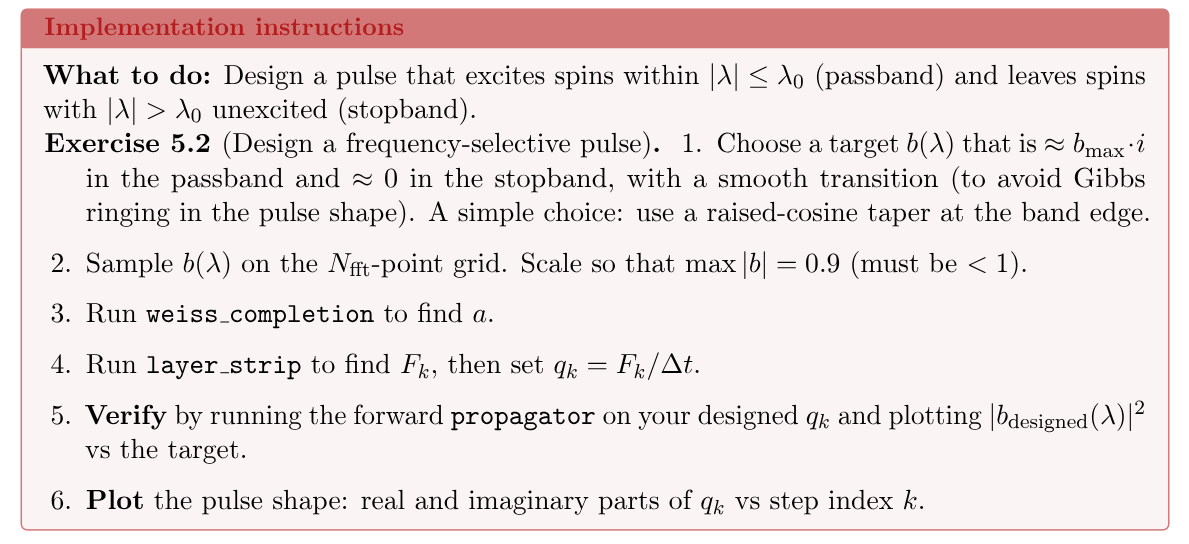

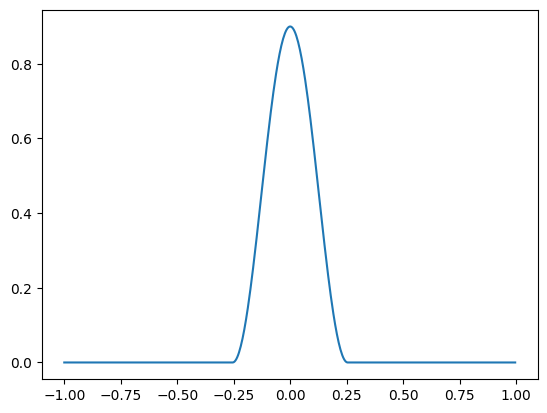

Poly error: 7.87328590307958e-14


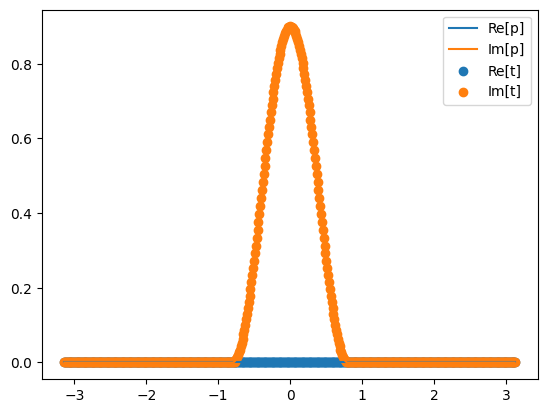

124
Length recovered: 249


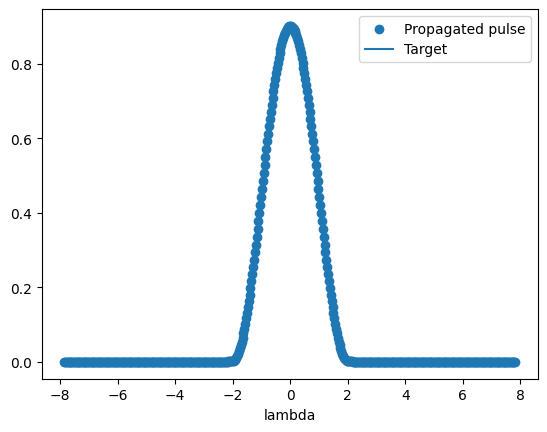

Found pulse sequence of length 249 that reproduces target. Max error: 0.0040384948181086955


In [97]:
def get_passband_target_b(l0, delta):
    def b(l):
        x = np.abs(l)
        if x <= l0 - delta/2:
            return 0.9j
        elif x >= l0 + delta/2:
            return 0j
        else:
            return 0.9j * 0.5 * (1+np.cos(np.pi*(x-l0+delta/2)/delta))
    return np.vectorize(b)


Nfft = 512
dt = 0.2

ls = np.linspace(-np.pi / (2 * dt), np.pi / (2 * dt), Nfft, endpoint=False)
ts = ls * 2 * dt

b_l = get_passband_target_b(1, 2)
b_vals = b_l(ls)

plt.plot(ts / np.pi, b_vals.imag)
plt.show()

N_layers = 64

c = np.fft.ifft(np.concat([b_vals[Nfft//2:], b_vals[:Nfft//2]]))
f = np.fft.fftfreq(Nfft, d=1.0/Nfft).astype(int)
b = LaurentPoly(c,f,sign = -1)
plt_poly_and_compare(b, (ts, b_vals))


# shift b to be all positive
support = b.ks[np.abs(b.c) > 1e-6]       # frequencies where b actually has content
m = int(max(-support.min(), support.max()))
print(m)
N_layers = 2*m + 1                        # determined by the target, NOT hardcoded 32

b_arr = np.zeros(N_layers, complex)
for k, v in zip(b.ks, b.c):
    kk = int(k) + m                       # shift so the real support starts at 0
    if 0 <= kk < N_layers:
        b_arr[kk] = v

a_arr = recover_a_arr(b_arr, Nfft)

Fk, qk = recover_drive(a_arr, b_arr, dt)
print(f"Length recovered: {len(qk)}")

verify_b_vals = np.array([propagator(qk, dt, l)[1,0] for l in ls])
plt.scatter(ls, np.abs(verify_b_vals), label="Propagated pulse")
plt.plot(ls, np.abs(b_l(ls)), label="Target")
plt.xlabel("lambda")
plt.legend()
plt.show()

max_err = np.max(np.abs(np.square(np.abs(b_l(ls))) - np.square(np.abs(verify_b_vals))))
print(f"Found pulse sequence of length {len(qk)} that reproduces target. Max error: {max_err}")